# Week 9 – Day 1 Lab
## Stable Diffusion: Text-to-Image Generation

### Objectives

By the end of this lab, you will:
- Generate images using Stable Diffusion.
- Understand how prompts influence image generation.
- Experiment with inference steps, CFG scale, and random seeds.
- Build a mini AI-generated image gallery.


# Step 1: Enable GPU Runtime

Stable Diffusion requires significant computational power to generate images efficiently. Google Colab provides free access to GPUs, which can greatly speed up image generation.

Before proceeding, switch your notebook to use a GPU.

### Instructions

1. Click **Runtime** in the top menu.
2. Select **Change runtime type**.
3. Under **Hardware accelerator**, choose **T4 GPU** (or any available GPU).
4. Click **Save**.

### Verify that the GPU is Available

Run the code cell below to check whether your notebook is connected to a GPU. If the GPU is available, the output should display the name of the GPU (e.g., NVIDIA Tesla T4).

In [1]:
import torch

if torch.cuda.is_available():
    print("✅ GPU is available!")
    print("GPU Name:", torch.cuda.get_device_name(0))
else:
    print("❌ GPU is not available. Please enable GPU from Runtime → Change runtime type.")

✅ GPU is available!
GPU Name: Tesla T4


# Step 2: Install Required Libraries

Stable Diffusion is not included in Google Colab by default, so we first need to install the required Python libraries.

The following packages will be installed:

- **diffusers** – Provides Stable Diffusion models.
- **transformers** – Used for text encoding.
- **accelerate** – Optimizes model execution.
- **safetensors** – Secure model loading.

Run the following cell to install these packages.

In [2]:
!pip install -q diffusers transformers accelerate safetensors

# Step 3: Import Required Libraries

Now that the required packages are installed, we need to import them into our notebook.

We will use:

- **torch** for tensor computations.
- **StableDiffusionPipeline** to load the pre-trained model.
- **matplotlib** to display generated images.

Run the following cell.

In [3]:
import torch
from diffusers import StableDiffusionPipeline
import matplotlib.pyplot as plt

Flax classes are deprecated and will be removed in Diffusers v0.40.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v0.40.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.


#Load the Stable Diffusion Model

Stable Diffusion is a pre-trained generative AI model capable of converting text descriptions into images.

In this step, we will load the model and prepare it for image generation.

**Note:** The first execution may take several minutes because the model needs to be downloaded.


Hints:

- Use StableDiffusionPipeline.from_pretrained()
- The model name is:
  runwayml/stable-diffusion-v1-5
- Move the pipeline to the GPU.

In [4]:
#write your code here
pipe = StableDiffusionPipeline.from_pretrained(
    "runwayml/stable-diffusion-v1-5",
    torch_dtype=torch.float16
)
pipe = pipe.to("cuda")

model_index.json:   0%|          | 0.00/541 [00:00<?, ?B/s]

Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 15 files:   0%|          | 0/15 [00:00<?, ?it/s]

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/396 [00:00<?, ?it/s]

# Generate Your First AI Image

Let's generate your first AI image!



Complete the code below to generate an image for the following prompt:

> "A futuristic city at sunset"

Display the generated image.

  0%|          | 0/50 [00:00<?, ?it/s]

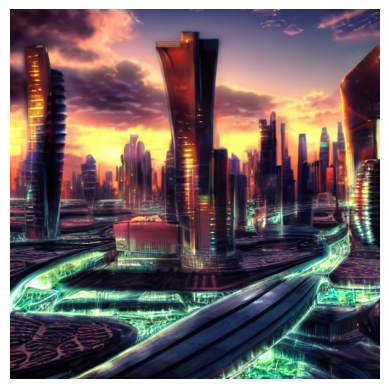

In [5]:
#write your code here
prompt = "A futuristic city at sunset"
image = pipe(prompt).images[0]

plt.imshow(image)
plt.axis("off")
plt.show()

# Experiment 1: Prompt Engineering

The quality of an AI-generated image depends greatly on the prompt.

Generate images using both prompts below.

### Prompt 1

Dog

### Prompt 2

A golden retriever running on a beach during sunset, cinematic lighting, highly detailed, realistic photography



generate both images.

  0%|          | 0/50 [00:00<?, ?it/s]

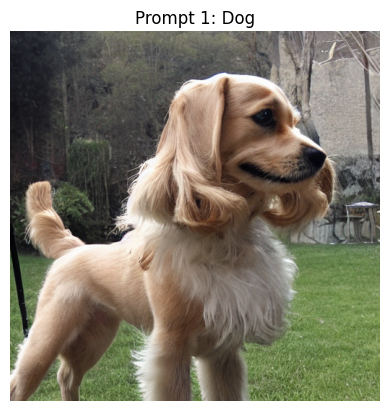

In [6]:
#write code here
prompt1 = "Dog"
image1 = pipe(prompt1).images[0]
plt.imshow(image1)
plt.axis("off")
plt.title("Prompt 1: Dog")
plt.show()

  0%|          | 0/50 [00:00<?, ?it/s]

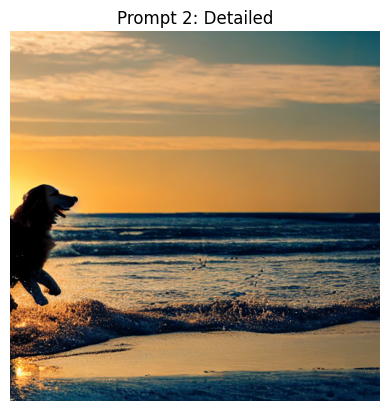

In [7]:
#write code here
prompt2 = "A golden retriever running on a beach during sunset, cinematic lighting, highly detailed, realistic photography"
image2 = pipe(prompt2).images[0]
plt.imshow(image2)
plt.axis("off")
plt.title("Prompt 2: Detailed")
plt.show()

## Reflection

1. Which prompt generated the better image?

2. Which image contained more details?

3. Why do detailed prompts usually produce better results?

In [ ]:
#answer here

1. Prompt 2 ("golden retriever...") generally produces a much better, more coherent image.

2. Prompt 2's image contains far more detail specific breed, setting, lighting, and photographic style.

3. Detailed prompts give the model more context to work with describing subject, action, environment, lighting, and style narrows down what the model generates, instead of leaving it to guess from a single vague word.

# Experiment 2: Inference Steps

Stable Diffusion gradually removes noise over multiple iterations.

These iterations are called **Inference Steps**.


Generate the same image using:

- 20 inference steps
- 50 inference steps

  0%|          | 0/20 [00:00<?, ?it/s]

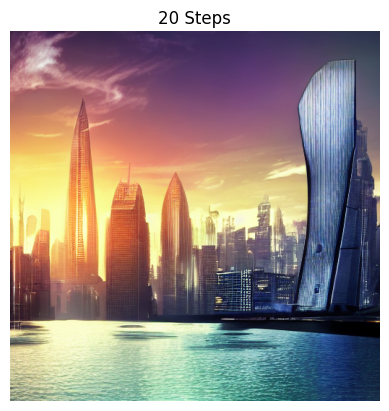

In [8]:
#write your code here
prompt = "A futuristic city at sunset"

image_20 = pipe(prompt, num_inference_steps=20).images[0]
plt.imshow(image_20)
plt.axis("off")
plt.title("20 Steps")
plt.show()

  0%|          | 0/50 [00:00<?, ?it/s]

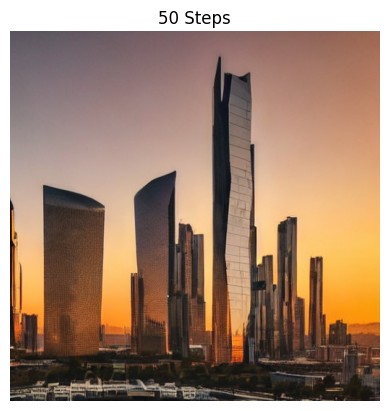

In [9]:
#write your code here
image_50 = pipe(prompt, num_inference_steps=50).images[0]
plt.imshow(image_50)
plt.axis("off")
plt.title("50 Steps")
plt.show()

## Reflection

- Which image looks sharper?

- Was there a noticeable improvement?

- Did image generation take longer?

In [ ]:
#answer here

* The 50-step image usually looks sharper and more refined.

* Yes, there's typically a noticeable improvement in detail and coherence, though the gains shrink beyond a certain point (diminishing returns).

* Yes — more steps means more denoising iterations, so generation takes longer.


# Experiment 3: Guidance Scale (CFG)

CFG controls how closely Stable Diffusion follows your prompt.


Generate the same prompt using:

- CFG = 5
- CFG = 8
- CFG = 12



  0%|          | 0/50 [00:00<?, ?it/s]

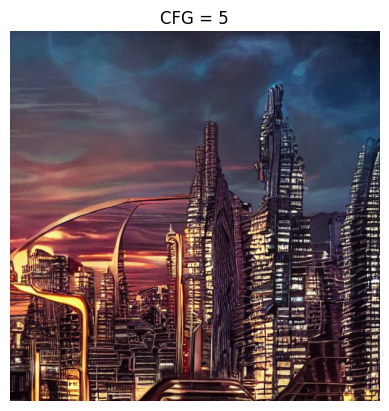

In [10]:
#write code here
prompt = "A futuristic city at sunset"

image_cfg5 = pipe(prompt, guidance_scale=5).images[0]
plt.imshow(image_cfg5)
plt.axis("off")
plt.title("CFG = 5")
plt.show()

  0%|          | 0/50 [00:00<?, ?it/s]

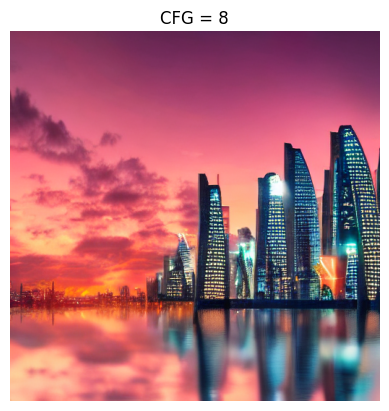

In [11]:
#write code here
image_cfg8 = pipe(prompt, guidance_scale=8).images[0]
plt.imshow(image_cfg8)
plt.axis("off")
plt.title("CFG = 8")
plt.show()

  0%|          | 0/50 [00:00<?, ?it/s]

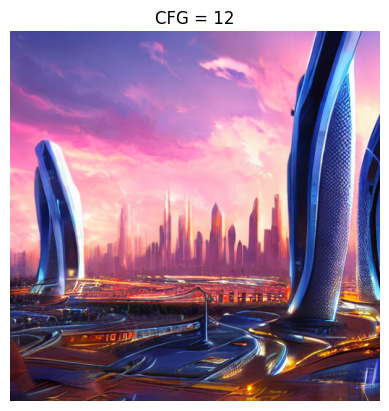

In [12]:
#write code here
image_cfg12 = pipe(prompt, guidance_scale=12).images[0]
plt.imshow(image_cfg12)
plt.axis("off")
plt.title("CFG = 12")
plt.show()

## Reflection

- Which CFG value produced the best image?

- Which image followed the prompt most accurately?

- What happens when CFG becomes too high?

In [ ]:
#answer here

* CFG = 8 usually produces the best balance of quality and creativity (this is the commonly recommended default).

* Higher CFG (like 12) tends to follow the prompt most literally/accurately.

* When CFG gets too high, images can become oversaturated, distorted, or overly "forced," losing natural detail and diversity.

# Experiment 4: Random Seed

Every image starts from random noise.

Changing the seed changes the starting noise, resulting in different images.



Complete the code below.

Generate images using the following seeds:

- 42
- 100
- 500



  0%|          | 0/50 [00:00<?, ?it/s]

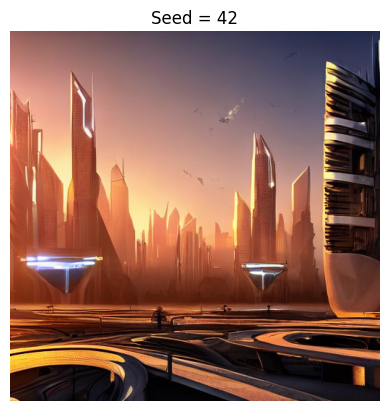

In [13]:
#write code here
prompt = "A futuristic city at sunset"

generator = torch.Generator("cuda").manual_seed(42)
image_seed42 = pipe(prompt, generator=generator).images[0]
plt.imshow(image_seed42)
plt.axis("off")
plt.title("Seed = 42")
plt.show()

  0%|          | 0/50 [00:00<?, ?it/s]

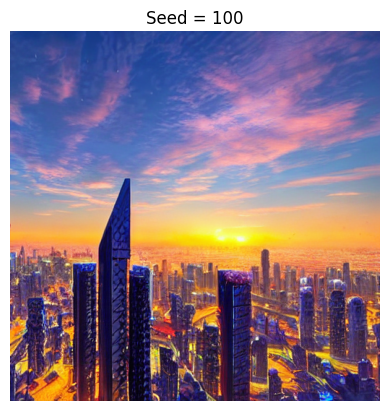

In [14]:
#write code here
generator = torch.Generator("cuda").manual_seed(100)
image_seed100 = pipe(prompt, generator=generator).images[0]
plt.imshow(image_seed100)
plt.axis("off")
plt.title("Seed = 100")
plt.show()

  0%|          | 0/50 [00:00<?, ?it/s]

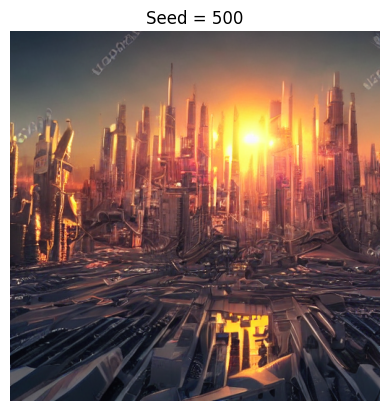

In [15]:
#write code here
generator = torch.Generator("cuda").manual_seed(500)
image_seed500 = pipe(prompt, generator=generator).images[0]
plt.imshow(image_seed500)
plt.axis("off")
plt.title("Seed = 500")
plt.show()

## Reflection

- Which seed generated your favorite image?

- What changed when the seed changed?

- Why are seeds useful when reproducing results?

In [ ]:
#answer here

* This is subjective — pick whichever seed's output you personally like best after running the cells.
* Changing the seed changes the initial random noise the model starts denoising from, so the overall composition, pose, and details of the image change even though the prompt stays the same.
* Seeds are useful for reproducibility — if you find an image you like, saving its seed lets you regenerate the exact same result later, or lets others recreate your output for comparison/debugging.